In [1]:
from memory_profiler import memory_usage
import matplotlib.pyplot as plt

In [2]:
import maboss

ipylab module is not installed, menus and toolbar are disabled.


### PopMaBoSS

In [3]:
mem_usage = {}

In [4]:
sim = maboss.PopSimulation("p53/p53_toy_pmb.pbnd", "p53/p53_toy_pmb.cfg")

In [5]:
sim.param["thread_count"] = 1

In [6]:
mem_usage.update({1:memory_usage(sim.run, include_children=True)})

In [7]:
sim.param["thread_count"] = 2

In [8]:
mem_usage.update({2:memory_usage(sim.run, include_children=True)})

In [9]:
sim.param["thread_count"] = 4

In [10]:
mem_usage.update({4:memory_usage(sim.run, include_children=True)})

In [11]:
sim.param["thread_count"] = 8

In [12]:
mem_usage.update({8:memory_usage(sim.run, include_children=True)})

In [13]:
sim.param["thread_count"] = 16

In [14]:
mem_usage.update({16:memory_usage(sim.run, include_children=True)})

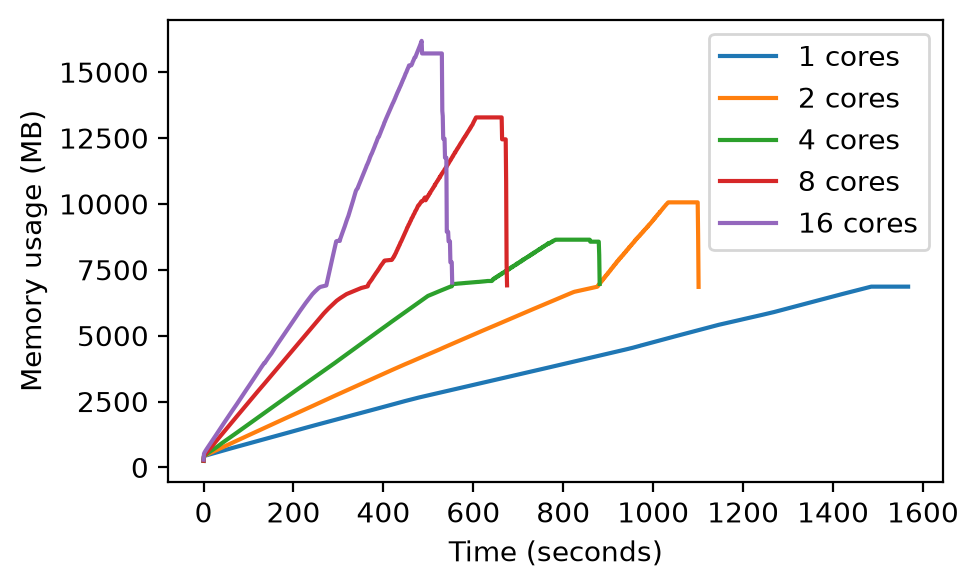

In [15]:
fig = plt.figure(figsize=(5,3), dpi=200)
for cores, mem in mem_usage.items():
    plt.plot(mem, label=f"{cores} cores")
plt.xlabel("Time (seconds)")
plt.ylabel("Memory usage (MB)")
plt.legend()

In [16]:
import pandas as pd
import numpy as np

In [17]:
maxes = {ncores:np.max(mem) for ncores, mem in mem_usage.items()}

<Axes: >

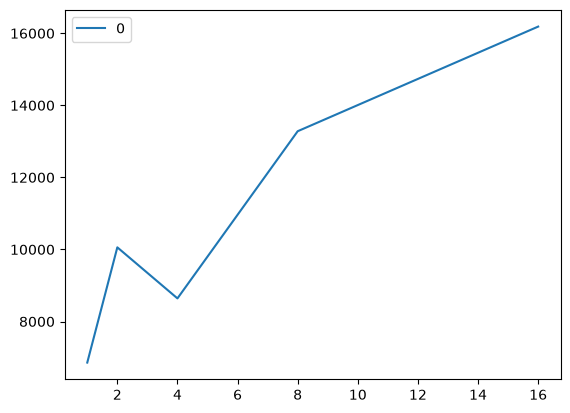

In [18]:
pd.DataFrame.from_dict(maxes, orient='index').plot()